In [1]:
# ===============================
# Core Python Libraries
# ===============================
import os
import re
import json
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from urllib.parse import urlparse
from scipy.special import expit  # Sigmoid function

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK & Gensim
# ===============================
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Preprocessing & Modeling (Scikit-learn, imbalanced-learn)
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# ===============================
# Deep Learning (TensorFlow / Keras)
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Input, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
import torch
from torch.optim import AdamW

# ===============================
# Progress Bar
# ===============================
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto

# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter

# ===============================
# Constants & Paths
# ===============================
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fraud_labels = ["Normal", "Fraud"]
transaction_type_labels = ["Bill Payment", "P2M","P2P", "Recharge"]
metrics_calculator_wlb = MetricsCalculator(fraud_labels)
metrics_calculator_cg = MetricsCalculator(transaction_type_labels)

In [3]:
def upload_dataset(file_path):
    """Load the dataset from a CSV file"""
    df = pd.read_csv(file_path,)
    return df

In [4]:
path=r"UPI Transactions 2024 Dataset.csv"

In [5]:
df= upload_dataset(path)
df

,transaction id,transaction_type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000170527,P2M,Food,526,SUCCESS,26-35,26-35,Tamil Nadu,ICICI,PNB,Android,4G,0,22,Friday,0
1,TXN0000248684,P2P,Healthcare,318,SUCCESS,36-45,36-45,Gujarat,Yes Bank,Axis,Android,4G,0,19,Sunday,1
2,TXN0000205744,P2M,Fuel,3176,SUCCESS,26-35,26-35,Tamil Nadu,HDFC,Kotak,Android,3G,0,17,Monday,0
3,TXN0000028152,P2P,Grocery,282,SUCCESS,26-35,18-25,Rajasthan,Kotak,ICICI,Android,4G,0,11,Sunday,1
4,TXN0000237943,P2P,Education,2418,SUCCESS,46-55,36-45,West Bengal,Kotak,IndusInd,Android,4G,0,16,Thursday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10862,TXN0000167824,Bill Payment,Other,406,SUCCESS,36-45,18-25,Maharashtra,SBI,PNB,Android,4G,0,19,Monday,0
10863,TXN0000224523,P2P,Grocery,260,SUCCESS,18-25,36-45,Karnataka,ICICI,SBI,iOS,3G,0,22,Saturday,1
10864,TXN0000192719,P2M,Utilities,333,SUCCESS,36-45,36-45,Uttar Pradesh,HDFC,SBI,Android,WiFi,0,18,Sunday,1
10865,TXN0000144455,Recharge,Utilities,199,SUCCESS,26-35,18-25,Gujarat,Yes Bank,SBI,Android,4G,0,14,Monday,0


In [6]:
tqdm.pandas()
label_encoders = {}

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

def preprocess_data(df=None, mode='train'):
    print(f"[INFO] Mode: {mode}")
    if df is None:
        raise ValueError("A valid DataFrame must be provided.")

    print("[INFO] Starting basic preprocessing...")

    # Replace nulls appropriately
    df = df.fillna({
        col: 0 if pd.api.types.is_numeric_dtype(df[col]) else 'unknown'
        for col in df.columns
    })

    # Extract age range columns and convert them
    age_cols = ['sender_age_group', 'receiver_age_group']
    for col in age_cols:
        if col in df.columns:
            df[f'{col}_min'] = df[col].apply(lambda x: int(x.split('-')[0]) if '-' in str(x) else 0)
            df[f'{col}_max'] = df[col].apply(lambda x: int(x.split('-')[1]) if '-' in str(x) else 0)
    df.drop(columns=[col for col in age_cols if col in df.columns], inplace=True)

    # Text preprocessing
    text_columns = df.select_dtypes(include='object').columns.tolist()
    
    # Remove target columns from text preprocessing
    targets = ['transaction_type', 'fraud_flag']
    text_columns = [col for col in text_columns if col not in targets]

    print(f"[INFO] Applying NLP preprocessing on: {text_columns}")
    for col in text_columns:
        df[col] = df[col].progress_apply(clean_text)

    # Combine all text columns into one
    df['combined_text'] = df[text_columns].agg(' '.join, axis=1)

    # Create the final feature set excluding target columns
    numeric_data = df.select_dtypes(include=[np.number])
    X = pd.concat([df[['combined_text']], numeric_data], axis=1)

    # Drop target columns from X if they still exist
    X = X.drop(columns=[col for col in targets if col in X.columns], errors='ignore')

    if mode == 'train':
        Y_dict = {}
        for target in targets:
            if target in df.columns:
                le = LabelEncoder()
                Y_dict[target] = le.fit_transform(df[target].astype(str))
                label_encoders[target] = le
        return X, Y_dict.get('transaction_type'), Y_dict.get('fraud_flag')

    elif mode == 'test':
        return X

    else:
        raise ValueError("mode must be either 'train' or 'test'")


In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ZIAUDDIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ZIAUDDIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
X,  Y_multiclass,Y_binary = preprocess_data(df, mode='train')

[INFO] Mode: train
[INFO] Starting basic preprocessing...
[INFO] Applying NLP preprocessing on: ['transaction id', 'merchant_category', 'transaction_status', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']


100%|█████████████████████████████████████████████████████████████████████████| 10867/10867 [00:00<00:00, 92574.65it/s]


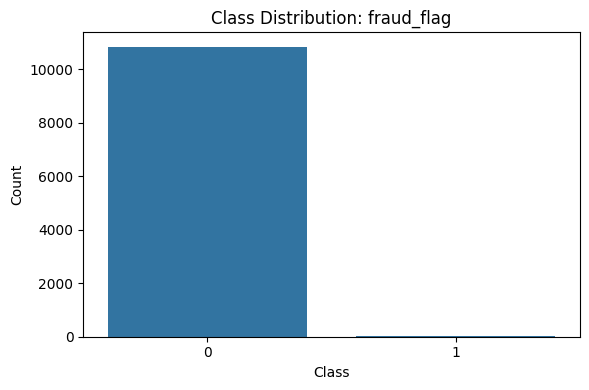

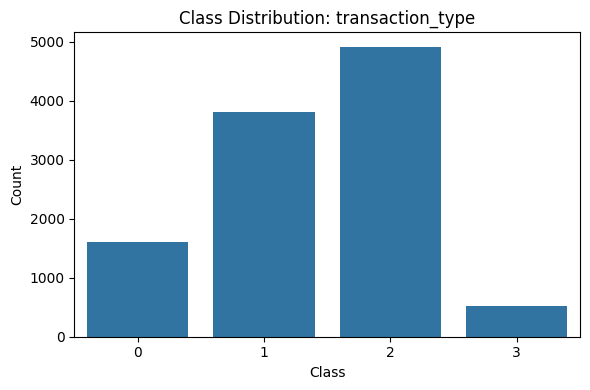

In [9]:
Y_dict = {'fraud_flag': Y_binary, 'transaction_type': Y_multiclass}

def plot_target_distributions(Y_dict):
    """
    Create count plots for each target column in Y_dict.
    
    Parameters:
        Y_dict (dict): Dictionary where keys are target column names and values are encoded label arrays.
    """
    # Convert to DataFrame for easy plotting
    y_df = pd.DataFrame(Y_dict)

    # Plot each column
    for col in y_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y_df[col])
        plt.title(f'Class Distribution: {col}')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
plot_target_distributions(Y_dict)


In [10]:
X

,combined_text,amount (INR),hour_of_day,is_weekend,sender_age_group_min,sender_age_group_max,receiver_age_group_min,receiver_age_group_max
0,txn food success tamil nadu icici pnb android ...,526,22,0,26,35,26,35
1,txn healthcare success gujarat yes bank axis a...,318,19,1,36,45,36,45
2,txn fuel success tamil nadu hdfc kotak android...,3176,17,0,26,35,26,35
3,txn grocery success rajasthan kotak icici andr...,282,11,1,26,35,18,25
4,txn education success west bengal kotak indusi...,2418,16,0,46,55,36,45
...,...,...,...,...,...,...,...,...
10862,txn success maharashtra sbi pnb android g monday,406,19,0,36,45,18,25
10863,txn grocery success karnataka icici sbi io g s...,260,22,1,18,25,36,45
10864,txn utility success uttar pradesh hdfc sbi and...,333,18,1,36,45,36,45
10865,txn utility success gujarat yes bank sbi andro...,199,14,0,26,35,18,25


In [11]:
def sbert_feature_extraction(texts, model_name='sentence-transformers/all-MiniLM-L6-v2', batch_size=32):
    """Extract SBERT features from texts with tqdm progress bar."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting SBERT embeddings"):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)

        token_embeddings = model_output.last_hidden_state
        attention_mask = encoded_input['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = input_mask_expanded.sum(dim=1)
        embeddings = sum_embeddings / sum_mask

        all_embeddings.append(embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    return X, model


In [12]:
def feature_extraction(X_df, method='Numerical_SBERT', model_dir='model', is_train=True):
    x_file = os.path.join(model_dir, f'X_{method}.pkl')
    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")
    model_name = 'sentence-transformers/all-mpnet-base-v2'

    # Extract the text column
    text_data = X_df['combined_text'].tolist()

    if is_train:
        if os.path.exists(x_file):
            print(f"[INFO] Loading cached features from {x_file}")
            X = joblib.load(x_file)
        else:
            print("[INFO] Computing SBERT features...")
            X, model = sbert_feature_extraction(text_data, model_name=model_name)
            joblib.dump(X, x_file)
    else:
        print("[INFO] Computing SBERT features for test...")
        X, model = sbert_feature_extraction(text_data, model_name=model_name)

    return X


In [13]:
features = feature_extraction(X, method='Numerical_SBERT',is_train=True)

[INFO] Feature extraction method: Numerical_SBERT, Train mode: True
[INFO] Loading cached features from model\X_Numerical_SBERT.pkl


In [14]:
smote = SMOTE(random_state=42)
features_smoted = {}
labels_smoted = {}

for i, (key, y) in enumerate(Y_dict.items(), start=1):
    X_resampled, y_resampled = smote.fit_resample(features, y)
    features_smoted[f'features{i}'] = X_resampled
    labels_smoted[f'Y{i}'] = y_resampled
    print(f"Balanced '{key}' class: features{i}.shape = {X_resampled.shape}, Y{i}.shape = {y_resampled.shape}")

features_dict = {
    'fraud_flag': features_smoted['features1'],
    'transaction_type': features_smoted['features2']
}

labels_dict = {
    'fraud_flag': labels_smoted['Y1'],
    'transaction_type': labels_smoted['Y2']
}

C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, c

Balanced 'fraud_flag' class: features1.shape = (21694, 768), Y1.shape = (21694,)
Balanced 'transaction_type' class: features2.shape = (19668, 768), Y2.shape = (19668,)


In [15]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

def train_multioutput_nb_classifier(Algorithm_prefix, features_dict, labels_dict, nb_type='gaussian'):
    nb_models = {}

    NB_CLASSIFIERS = {
        'gaussian': GaussianNB,
        'bernoulli': BernoulliNB,
        'multinomial': MultinomialNB,
    }

    if nb_type not in NB_CLASSIFIERS:
        raise ValueError(f"Invalid nb_type '{nb_type}'. Must be one of {list(NB_CLASSIFIERS.keys())}.")

    NBClass = NB_CLASSIFIERS[nb_type]

    for target_name, y_encoded in labels_dict.items():
        features = features_dict.get(target_name)

        if features is None:
            print(f"[ERROR] No features found for target: {target_name}")
            continue

        model_path = f"model/{Algorithm_prefix}_{target_name}_{nb_type}nb_model.pkl"
        algo_name = f"{Algorithm_prefix} {nb_type.capitalize()}NB [{target_name}]"

        X_train, X_test, y_train, y_test = train_test_split(features, y_encoded, test_size=0.2, random_state=42)

        if os.path.exists(model_path):
            print(f"Loading existing {nb_type.capitalize()}NB model for {target_name}...")
            nb_model = joblib.load(model_path)
        else:
            print(f"Training {nb_type.capitalize()}NB for target: {target_name}...")
            nb_model = NBClass()
            nb_model.fit(X_train, y_train)
            joblib.dump(nb_model, model_path)

        y_pred = nb_model.predict(X_test)

        # Get predicted probabilities
        try:
            y_score = nb_model.predict_proba(X_test)
        except AttributeError:
            try:
                y_score = expit(nb_model.predict_log_proba(X_test).reshape(-1, 1))
            except:
                y_score = None

        # Use target-specific metrics calculator
        if target_name == "fraud_flag":
            metrics_calculator_wlb.calculate_metrics(algo_name, y_pred, y_test, y_score)
        elif target_name == "transaction_type":
            metrics_calculator_cg.calculate_metrics(algo_name, y_pred, y_test, y_score)
        else:
            print(f"No metrics_calculator defined for: {target_name}")

        nb_models[target_name] = nb_model

    return nb_models


Loading existing GaussianNB model for fraud_flag...


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ZIAUDDIN\OneDrive\Desktop\31. UPI Shield\UPI Shield Jupyter Notebook\metrics_calculator.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.metrics_df = pd.concat([self.metrics_df, metrics_entry], ignore_index=True)
C:\Users\ZIAUDDIN\OneDrive\Desktop\31. UPI Shield\UPI Shield Jupyter Notebook\metrics_calculat

Numerical BERT GaussianNB [fraud_flag] Accuracy  : 85.48
Numerical BERT GaussianNB [fraud_flag] Precision : 85.84
Numerical BERT GaussianNB [fraud_flag] Recall    : 85.46
Numerical BERT GaussianNB [fraud_flag] FScore    : 85.44
Numerical BERT GaussianNB [fraud_flag] Classification Report
Numerical BERT GaussianNB [fraud_flag]
              precision    recall  f1-score   support

      Normal       0.82      0.90      0.86      2179
       Fraud       0.89      0.80      0.85      2160

    accuracy                           0.85      4339
   macro avg       0.86      0.85      0.85      4339
weighted avg       0.86      0.85      0.85      4339




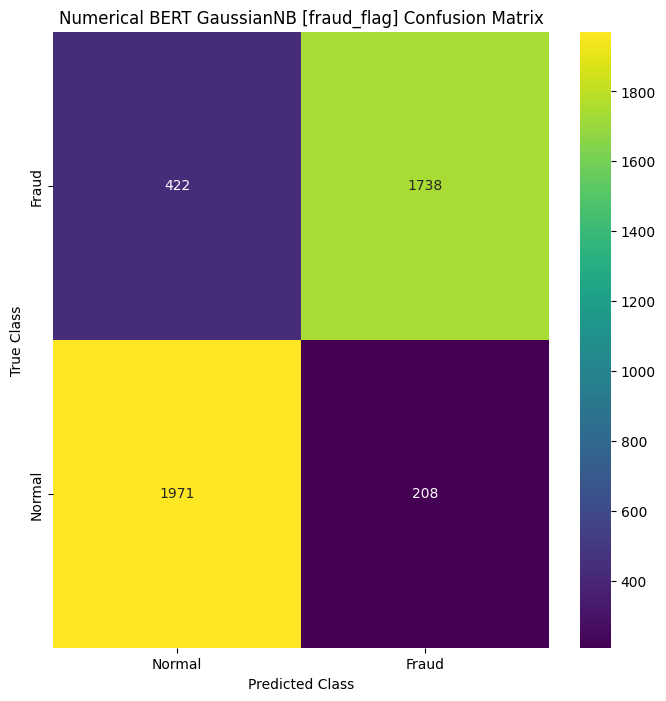

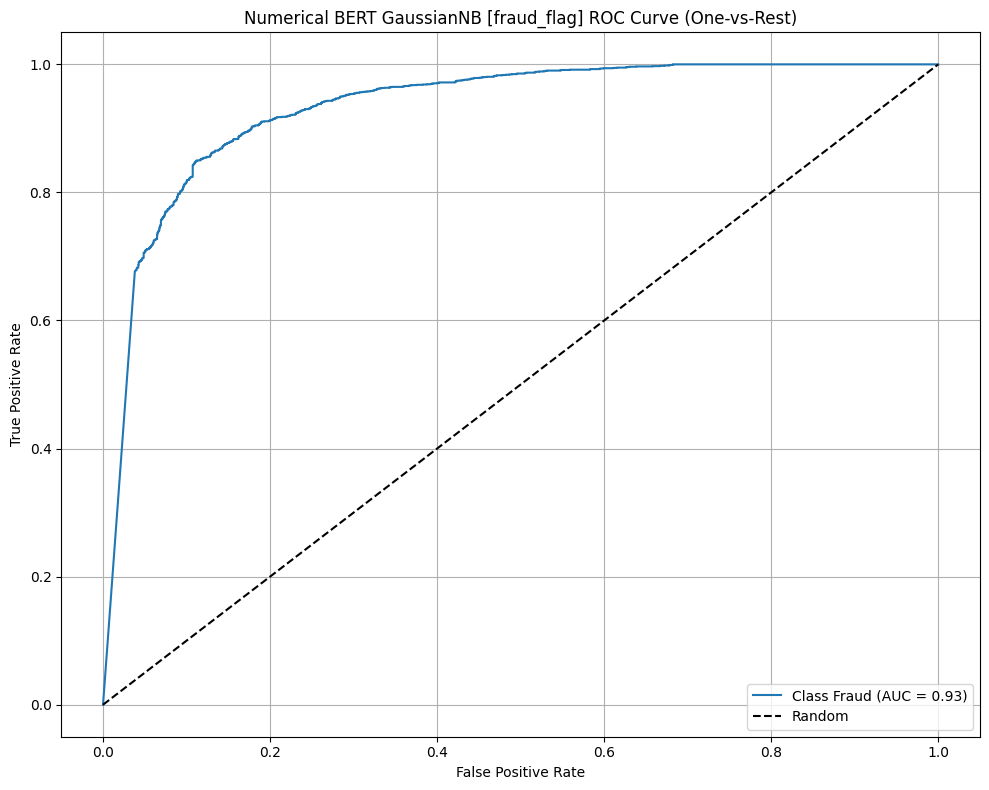

Loading existing GaussianNB model for transaction_type...


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ZIAUDDIN\OneDrive\Desktop\31. UPI Shield\UPI Shield Jupyter Notebook\metrics_calculator.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.metrics_df = pd.concat([self.metrics_df, metrics_entry], ignore_index=True)
C:\Users\ZIAUDDIN\OneDrive\Desktop\31. UPI Shield\UPI Shield Jupyter Notebook\metrics_calculat

Numerical BERT GaussianNB [transaction_type] Accuracy  : 30.33
Numerical BERT GaussianNB [transaction_type] Precision : 30.27
Numerical BERT GaussianNB [transaction_type] Recall    : 30.59
Numerical BERT GaussianNB [transaction_type] FScore    : 29.34
Numerical BERT GaussianNB [transaction_type] Classification Report
Numerical BERT GaussianNB [transaction_type]
              precision    recall  f1-score   support

Bill Payment       0.31      0.32      0.31       986
         P2M       0.30      0.16      0.21      1005
         P2P       0.30      0.25      0.27       996
    Recharge       0.30      0.49      0.37       947

    accuracy                           0.30      3934
   macro avg       0.30      0.31      0.29      3934
weighted avg       0.30      0.30      0.29      3934




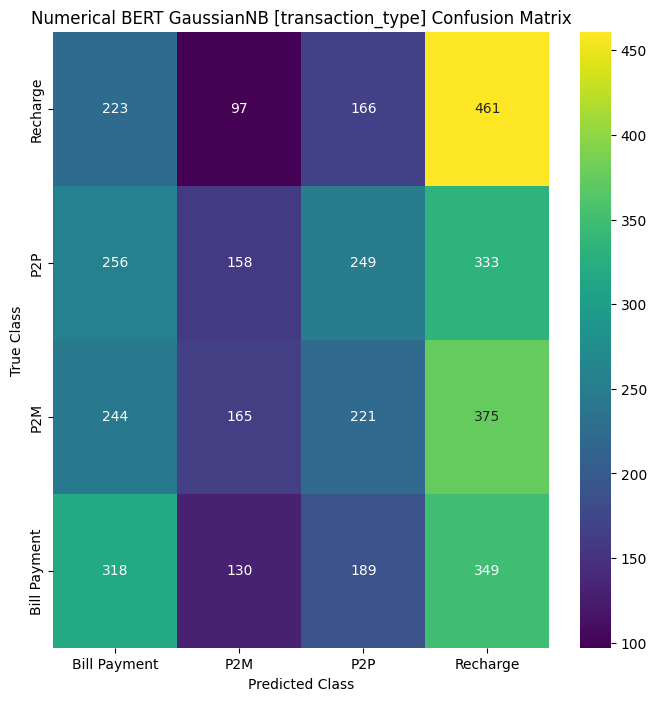

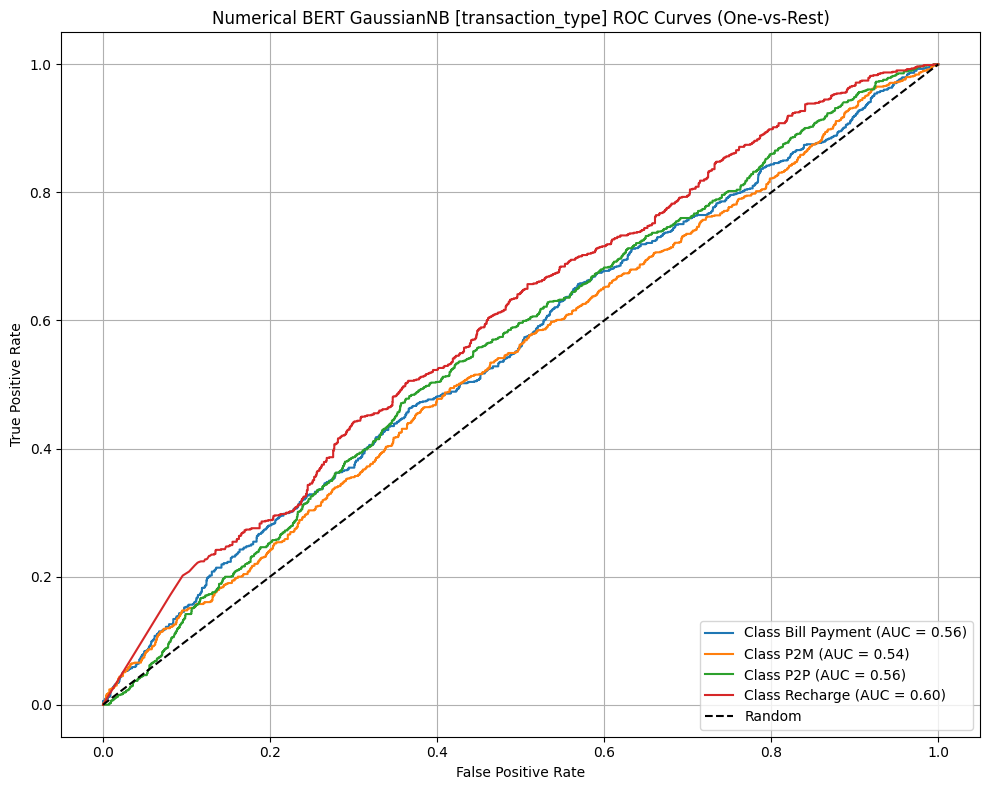

In [16]:
features_dict_positive = {k: np.abs(v) for k, v in features_dict.items()}
GNB_MODELS = train_multioutput_nb_classifier("Numerical BERT", features_dict_positive, labels_dict, nb_type='gaussian')

Loading existing BernoulliNB model for fraud_flag...
Numerical BERT BernoulliNB [fraud_flag] Accuracy  : 49.78
Numerical BERT BernoulliNB [fraud_flag] Precision : 24.89
Numerical BERT BernoulliNB [fraud_flag] Recall    : 50.00
Numerical BERT BernoulliNB [fraud_flag] FScore    : 33.24
Numerical BERT BernoulliNB [fraud_flag] Classification Report
Numerical BERT BernoulliNB [fraud_flag]
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      2179
       Fraud       0.50      1.00      0.66      2160

    accuracy                           0.50      4339
   macro avg       0.25      0.50      0.33      4339
weighted avg       0.25      0.50      0.33      4339




C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator BernoulliNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

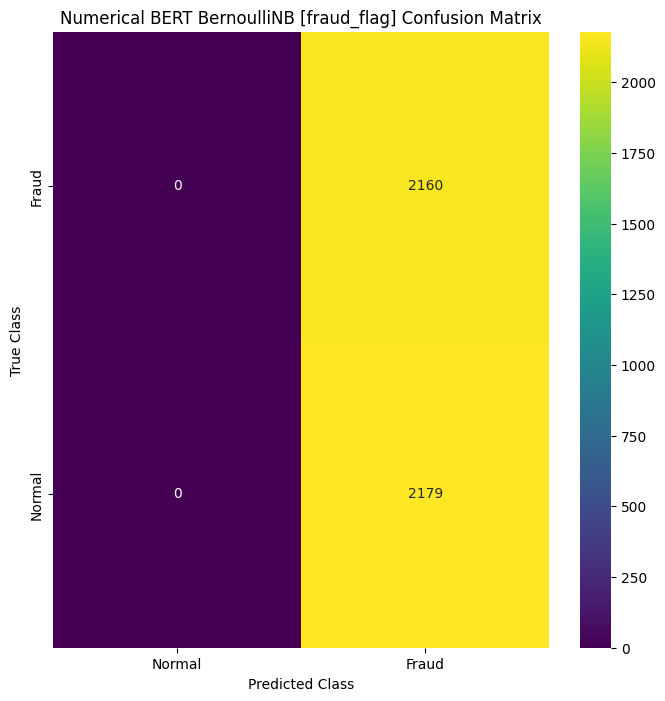

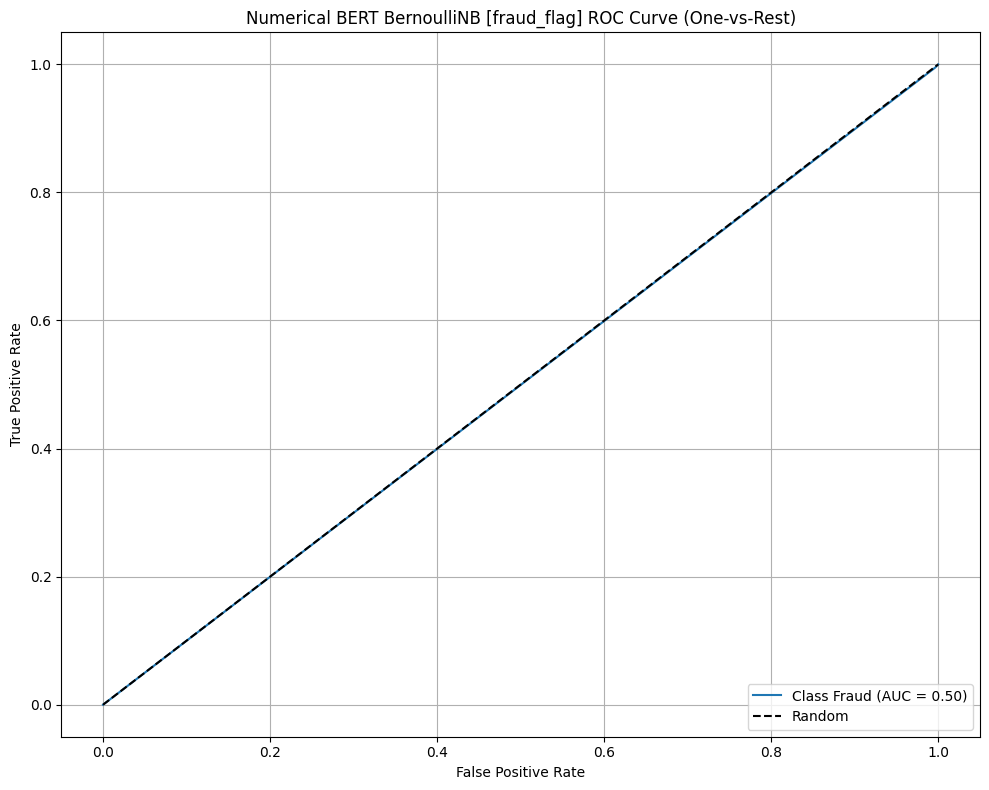

Loading existing BernoulliNB model for transaction_type...


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator BernoulliNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

Numerical BERT BernoulliNB [transaction_type] Accuracy  : 24.07
Numerical BERT BernoulliNB [transaction_type] Precision : 6.02
Numerical BERT BernoulliNB [transaction_type] Recall    : 25.00
Numerical BERT BernoulliNB [transaction_type] FScore    : 9.70
Numerical BERT BernoulliNB [transaction_type] Classification Report
Numerical BERT BernoulliNB [transaction_type]
              precision    recall  f1-score   support

Bill Payment       0.00      0.00      0.00       986
         P2M       0.00      0.00      0.00      1005
         P2P       0.00      0.00      0.00       996
    Recharge       0.24      1.00      0.39       947

    accuracy                           0.24      3934
   macro avg       0.06      0.25      0.10      3934
weighted avg       0.06      0.24      0.09      3934




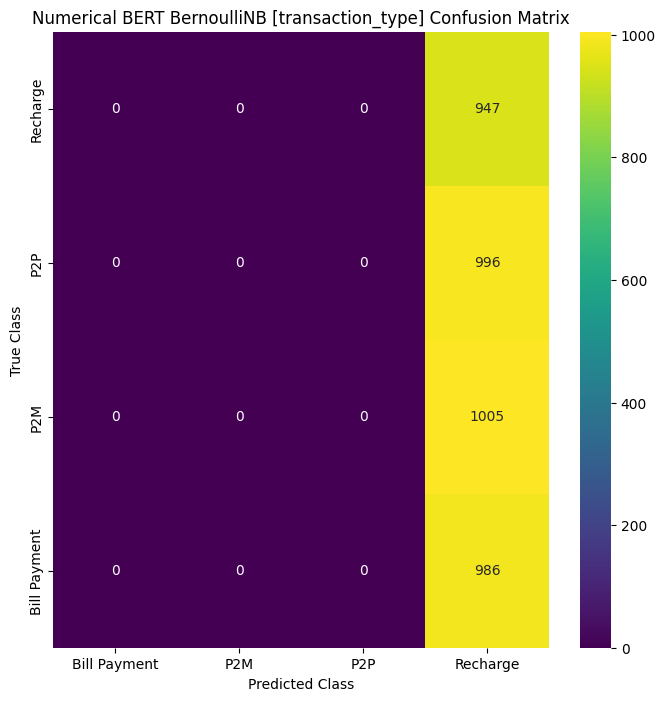

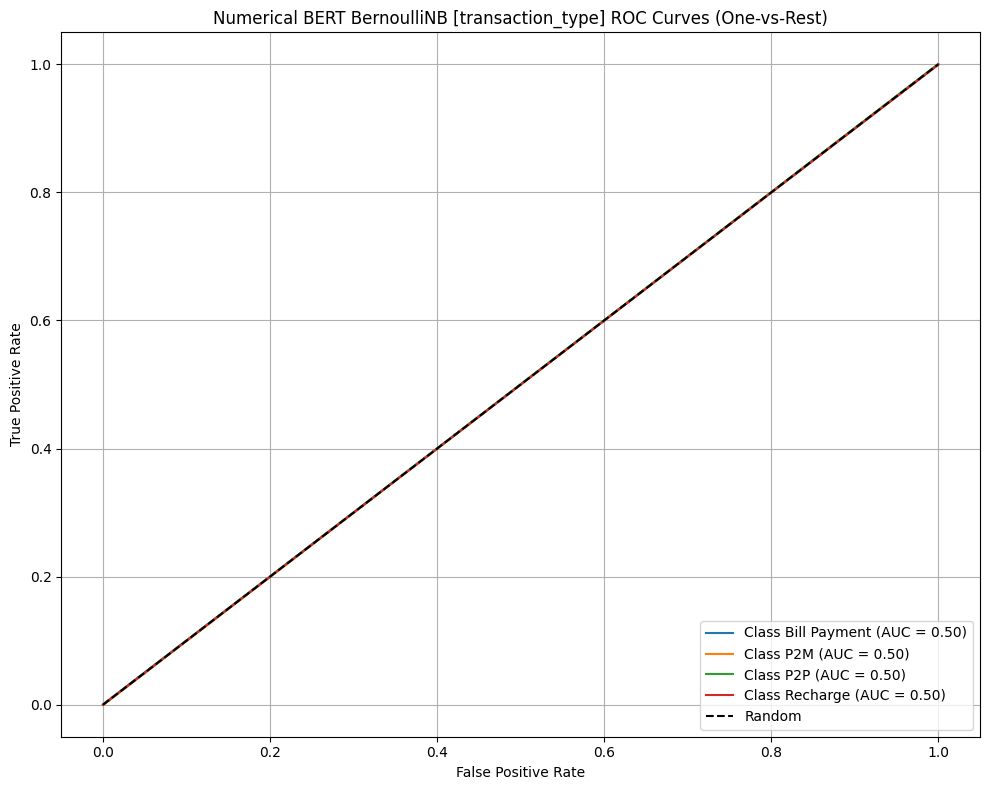

In [17]:
features_dict_positive = {k: np.abs(v) for k, v in features_dict.items()}
GNB_MODELS = train_multioutput_nb_classifier("Numerical BERT", features_dict_positive, labels_dict, nb_type='bernoulli')

Loading existing MultinomialNB model for fraud_flag...
Numerical BERT MultinomialNB [fraud_flag] Accuracy  : 75.69
Numerical BERT MultinomialNB [fraud_flag] Precision : 76.33
Numerical BERT MultinomialNB [fraud_flag] Recall    : 75.65
Numerical BERT MultinomialNB [fraud_flag] FScore    : 75.52


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Numerical BERT MultinomialNB [fraud_flag] Classification Report
Numerical BERT MultinomialNB [fraud_flag]
              precision    recall  f1-score   support

      Normal       0.72      0.84      0.78      2179
       Fraud       0.80      0.68      0.73      2160

    accuracy                           0.76      4339
   macro avg       0.76      0.76      0.76      4339
weighted avg       0.76      0.76      0.76      4339




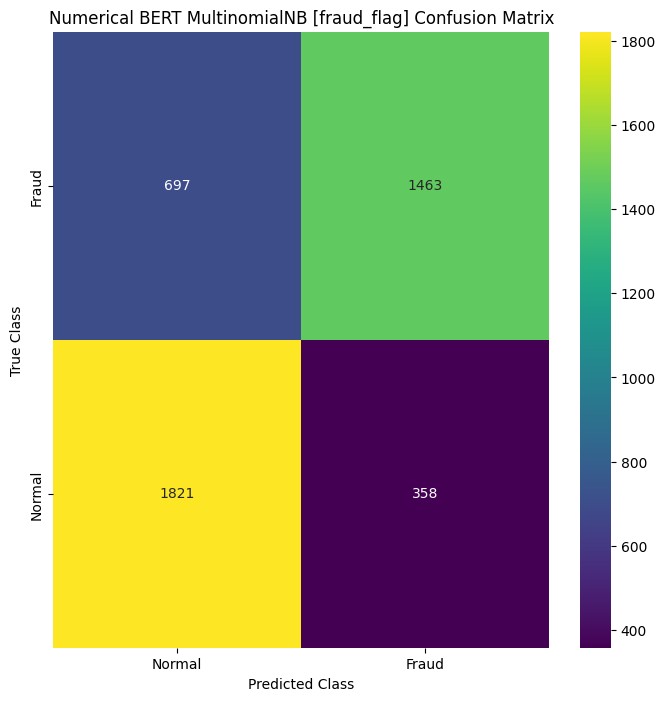

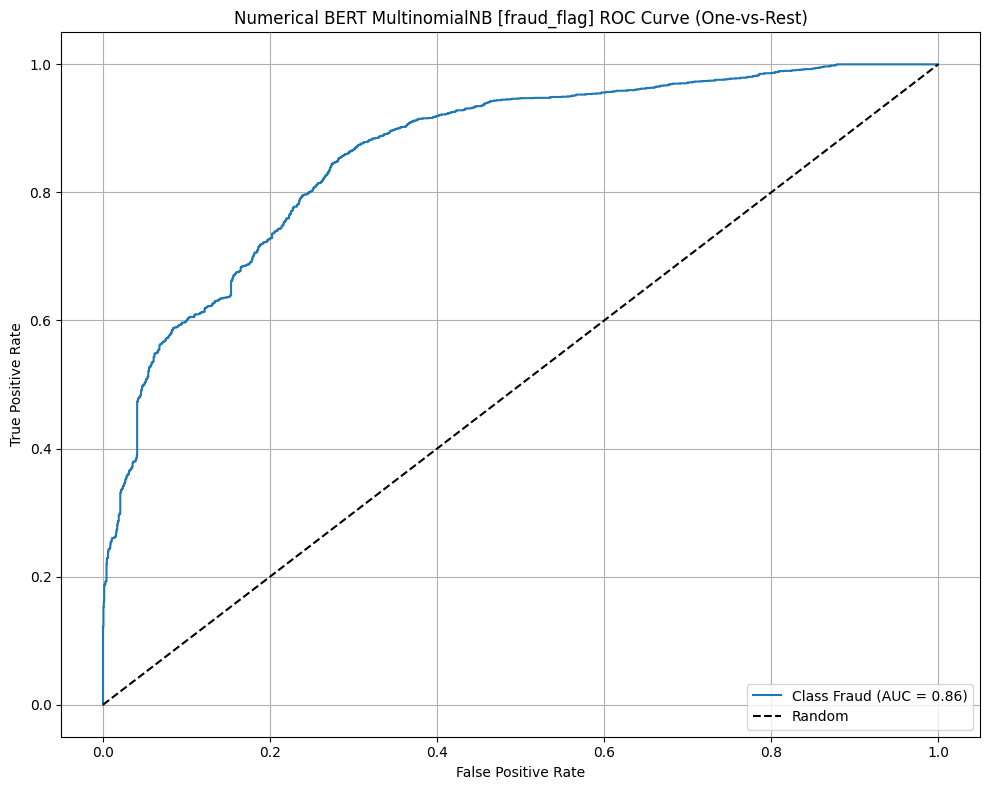

Loading existing MultinomialNB model for transaction_type...
Numerical BERT MultinomialNB [transaction_type] Accuracy  : 28.32
Numerical BERT MultinomialNB [transaction_type] Precision : 28.55
Numerical BERT MultinomialNB [transaction_type] Recall    : 28.54
Numerical BERT MultinomialNB [transaction_type] FScore    : 27.43
Numerical BERT MultinomialNB [transaction_type] Classification Report
Numerical BERT MultinomialNB [transaction_type]
              precision    recall  f1-score   support

Bill Payment       0.29      0.31      0.30       986
         P2M       0.29      0.15      0.19      1005
         P2P       0.29      0.25      0.27       996
    Recharge       0.27      0.44      0.33       947

    accuracy                           0.28      3934
   macro avg       0.29      0.29      0.27      3934
weighted avg       0.29      0.28      0.27      3934




C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


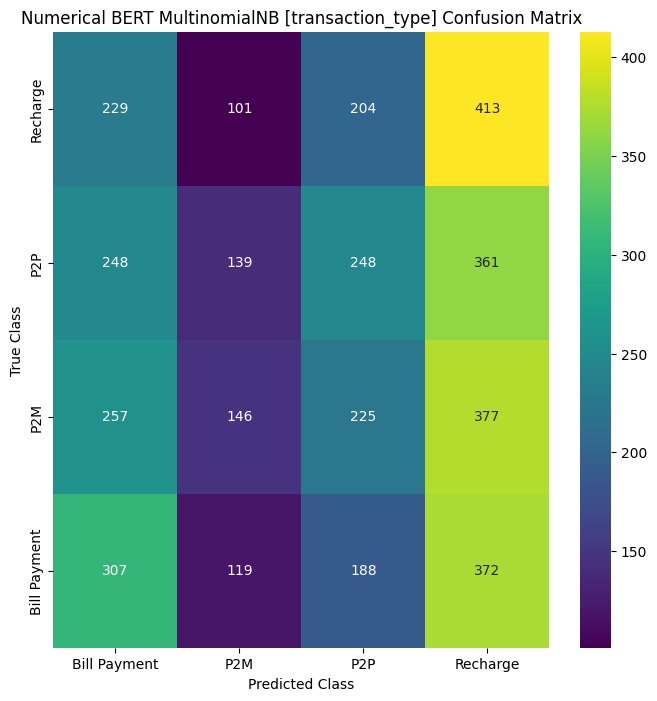

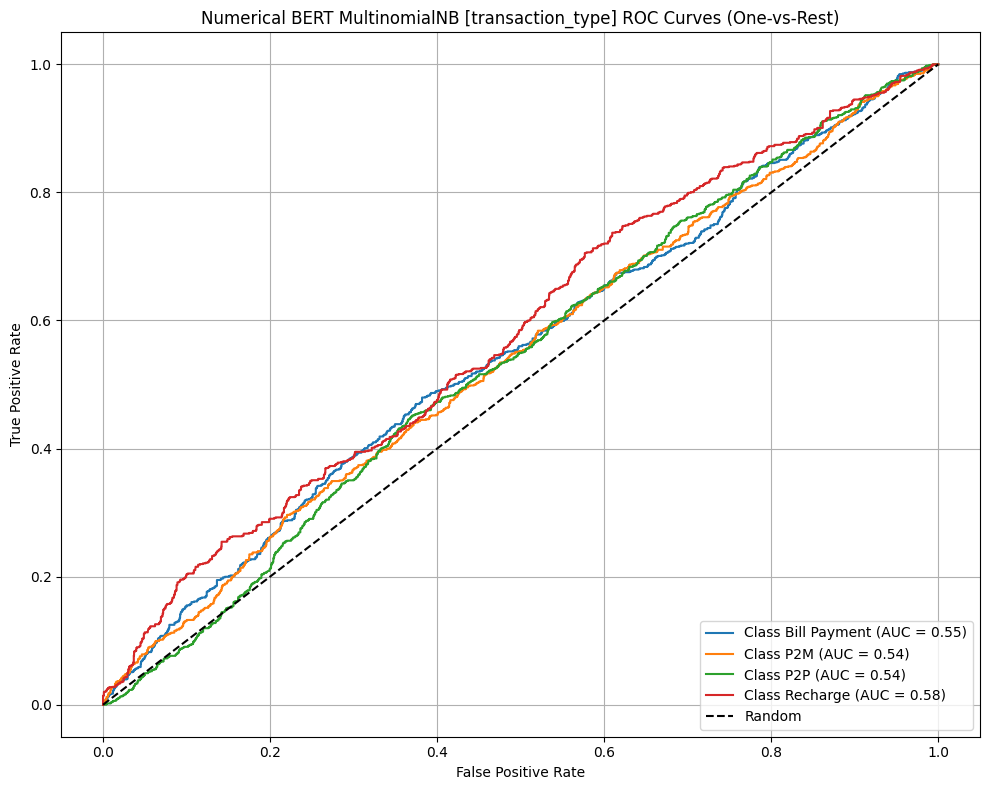

In [18]:
features_dict_positive = {k: np.abs(v) for k, v in features_dict.items()}
GNB_MODELS = train_multioutput_nb_classifier("Numerical BERT", features_dict_positive, labels_dict, nb_type='multinomial')

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
def train_multioutput_histgb_classifier(Algorithm_prefix, features_dict, labels_dict):
    histgb_models = {}

    for target_name, y_encoded in labels_dict.items():
        features = features_dict.get(target_name)

        if features is None:
            print(f"[ERROR] No features found for target: {target_name}")
            continue

        model_path = f"model/{Algorithm_prefix}_{target_name}_histgb_model.pkl"
        algo_name = f"{Algorithm_prefix} HGB [{target_name}]"

        X_train, X_test, y_train, y_test = train_test_split(features, y_encoded, test_size=0.2, random_state=42)

        if os.path.exists(model_path):
            print(f"Loading existing HistGradientBoostingClassifier model for {target_name}...")
            histgb = joblib.load(model_path)
        else:
            print(f"Training HistGradientBoostingClassifier for target: {target_name}...")
            histgb = HistGradientBoostingClassifier()
            histgb.fit(X_train, y_train)
            joblib.dump(histgb, model_path)

        y_pred = histgb.predict(X_test)

        # Try getting predicted probabilities
        try:
            y_score = histgb.predict_proba(X_test)
        except AttributeError:
            try:
                y_score = expit(histgb.decision_function(X_test).reshape(-1, 1))
            except:
                y_score = None

        # Use target-specific metrics calculator
        if target_name == "fraud_flag":
            metrics_calculator_wlb.calculate_metrics(algo_name, y_pred, y_test, y_score)
        elif target_name == "transaction_type":
            metrics_calculator_cg.calculate_metrics(algo_name, y_pred, y_test, y_score)
        else:
            print(f"No metrics_calculator defined for: {target_name}")

        histgb_models[target_name] = histgb

    return histgb_models


Loading existing HistGradientBoostingClassifier model for fraud_flag...


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Numerical BERT HGB [fraud_flag] Accuracy  : 99.98
Numerical BERT HGB [fraud_flag] Precision : 99.98
Numerical BERT HGB [fraud_flag] Recall    : 99.98
Numerical BERT HGB [fraud_flag] FScore    : 99.98
Numerical BERT HGB [fraud_flag] Classification Report
Numerical BERT HGB [fraud_flag]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2179
       Fraud       1.00      1.00      1.00      2160

    accuracy                           1.00      4339
   macro avg       1.00      1.00      1.00      4339
weighted avg       1.00      1.00      1.00      4339




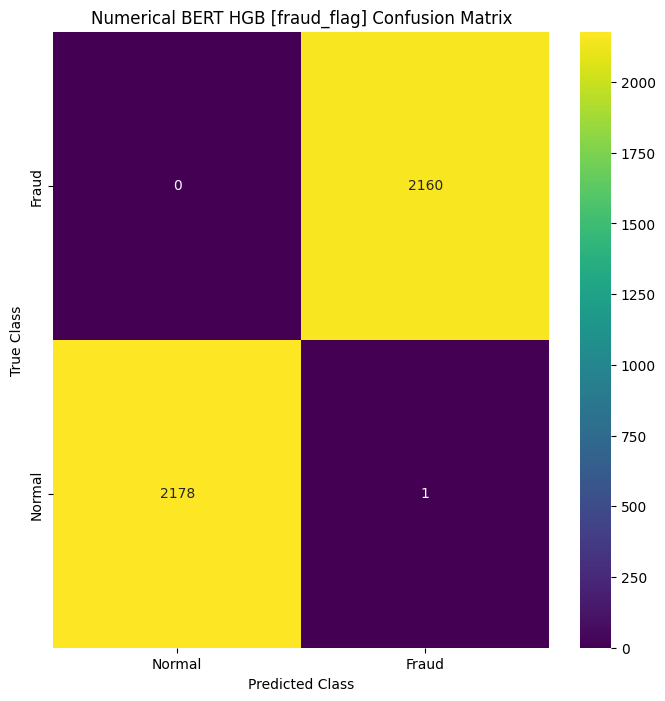

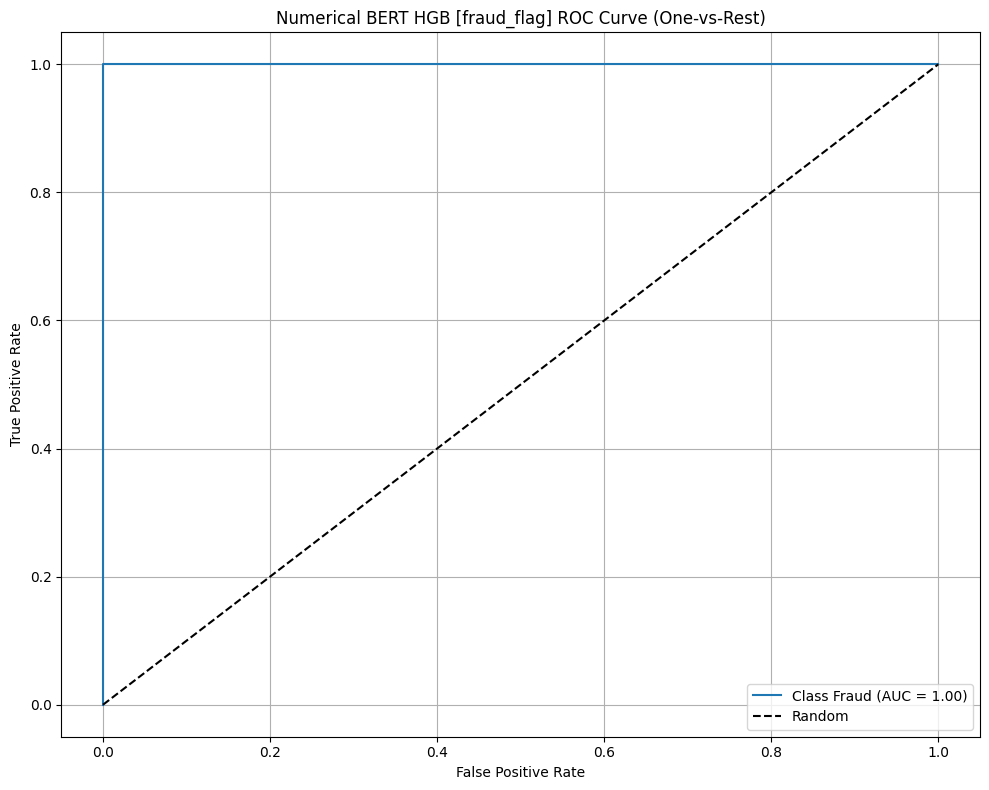

Loading existing HistGradientBoostingClassifier model for transaction_type...


C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ZIAUDDIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Numerical BERT HGB [transaction_type] Accuracy  : 84.44
Numerical BERT HGB [transaction_type] Precision : 84.33
Numerical BERT HGB [transaction_type] Recall    : 84.66
Numerical BERT HGB [transaction_type] FScore    : 84.44
Numerical BERT HGB [transaction_type] Classification Report
Numerical BERT HGB [transaction_type]
              precision    recall  f1-score   support

Bill Payment       0.86      0.91      0.88       986
         P2M       0.80      0.75      0.78      1005
         P2P       0.76      0.73      0.75       996
    Recharge       0.95      0.99      0.97       947

    accuracy                           0.84      3934
   macro avg       0.84      0.85      0.84      3934
weighted avg       0.84      0.84      0.84      3934




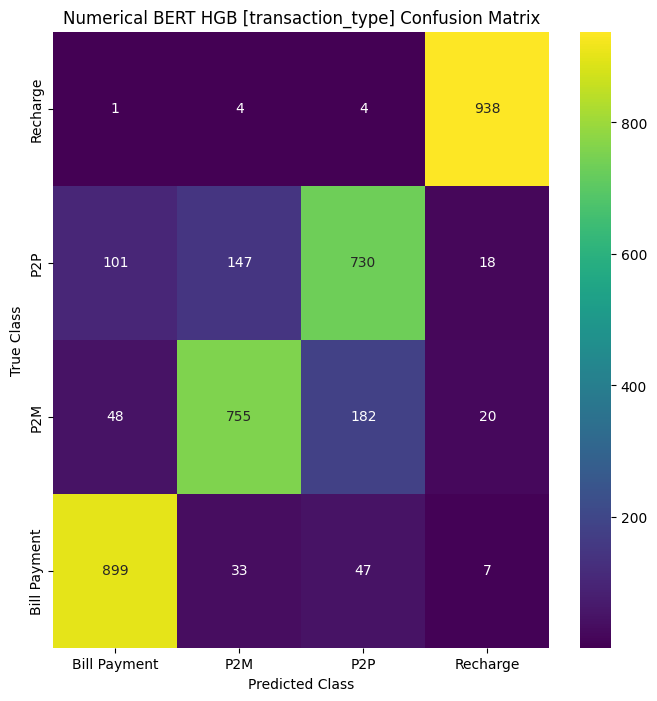

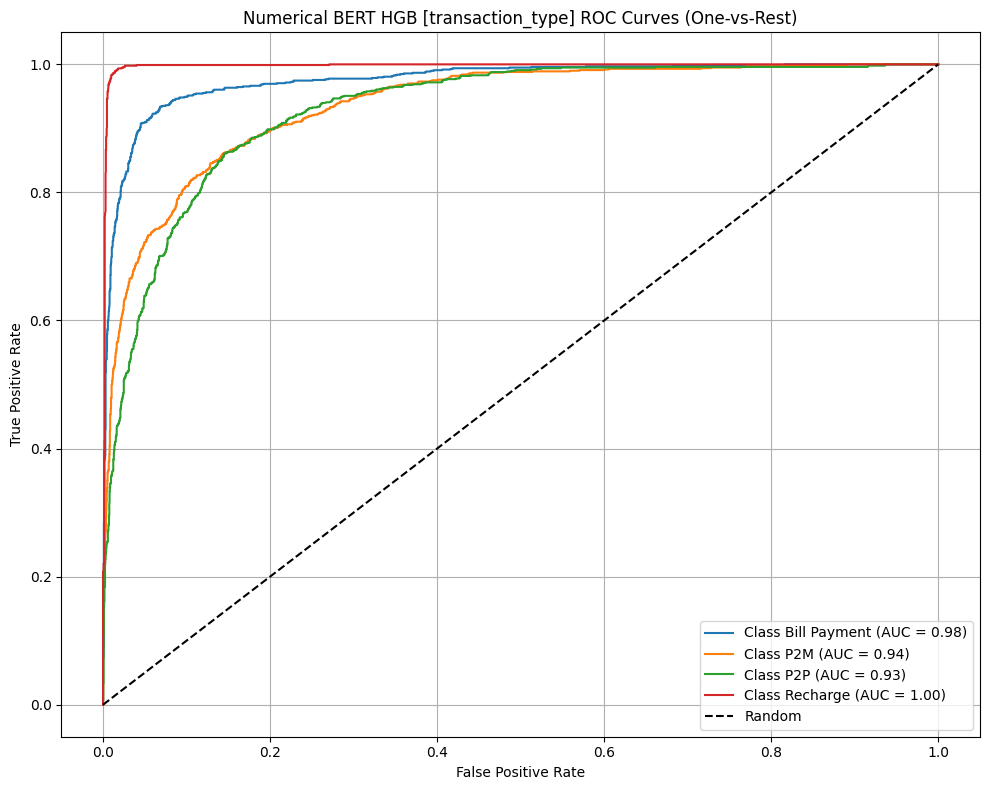

In [20]:
histgb_models = train_multioutput_histgb_classifier("Numerical BERT", features_dict, labels_dict)

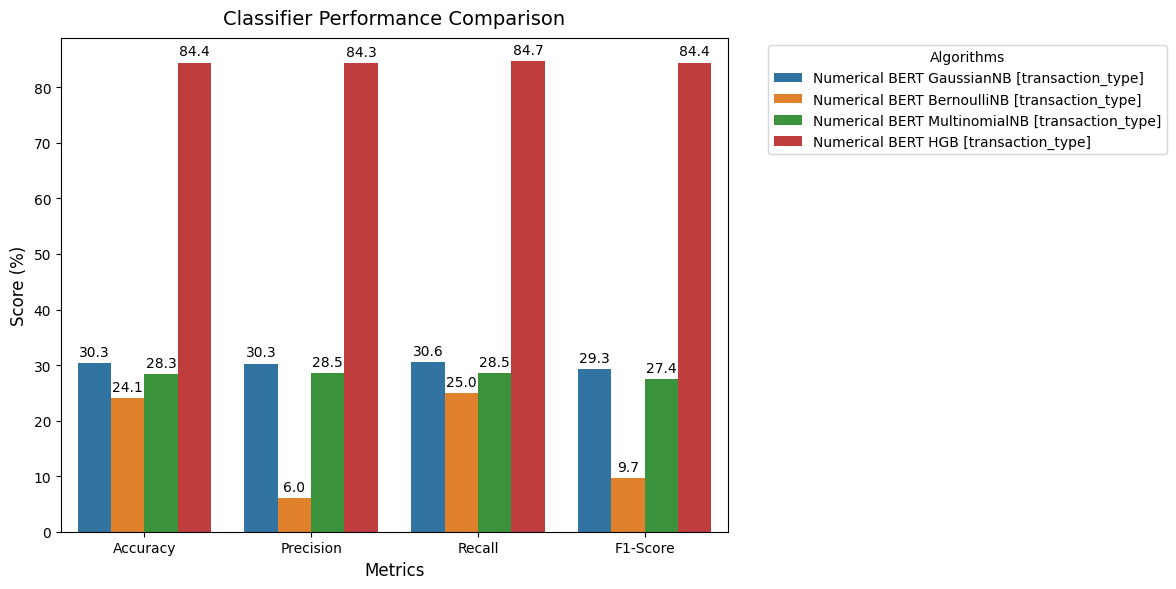

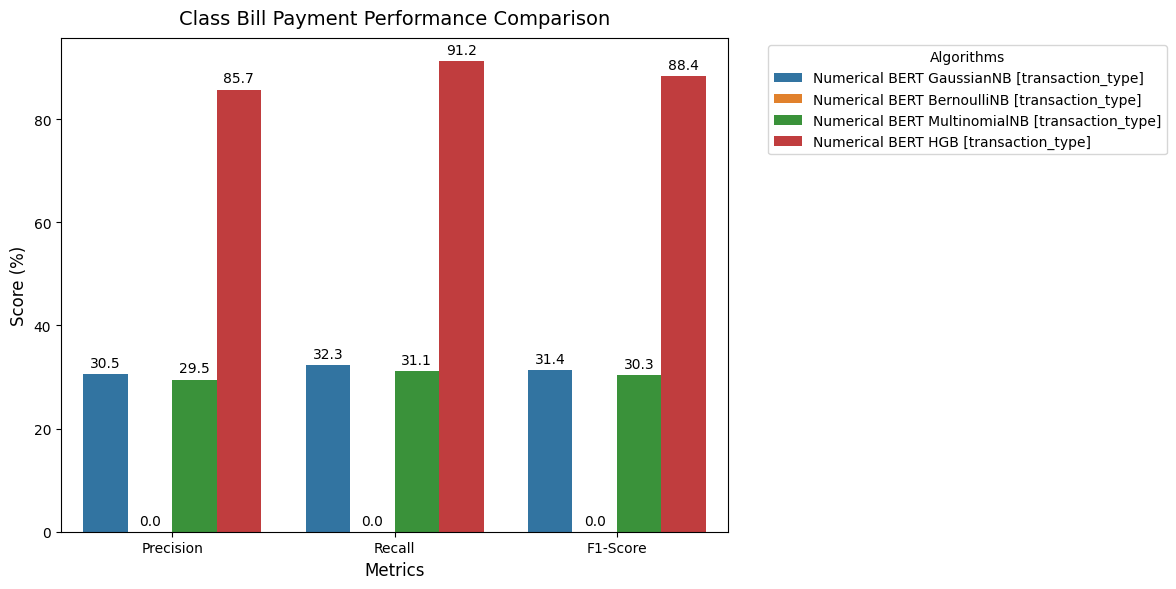

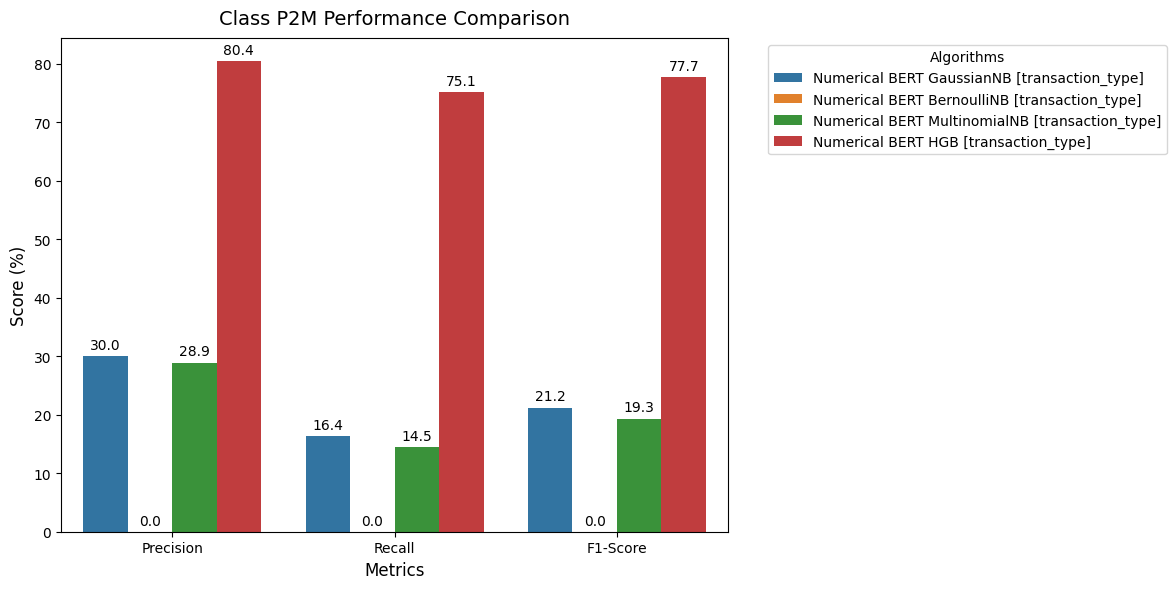

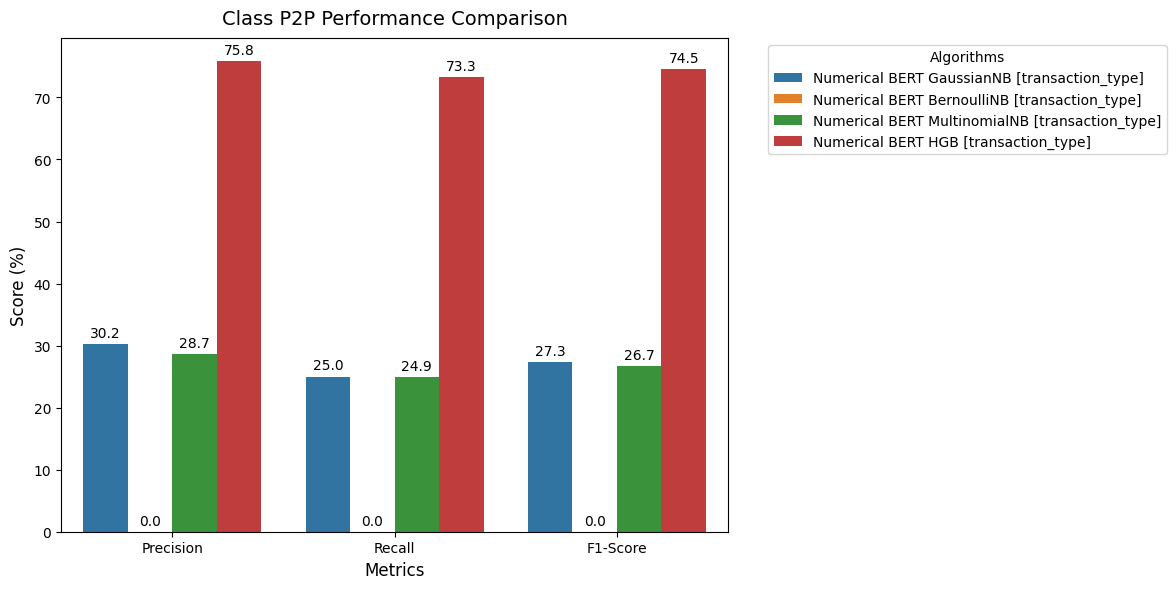

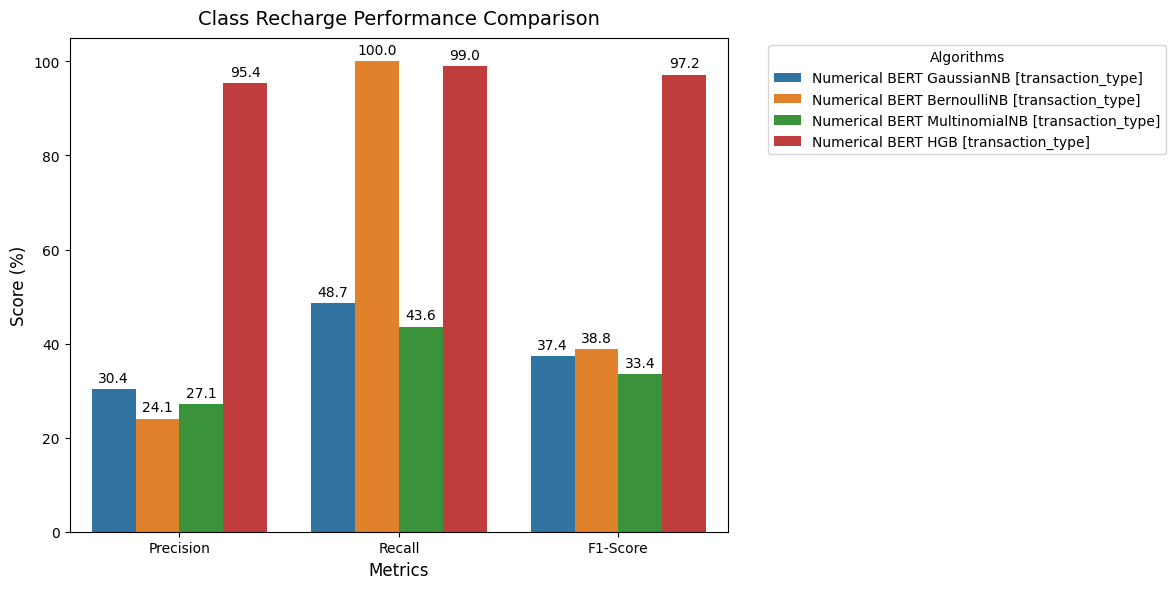

In [21]:
# Plot for Career Growth
graph_plotter_cg = GraphPlotter(metrics_calculator_cg.metrics_df, metrics_calculator_cg.class_performance_dfs)
graph_plotter_cg.plot_all()

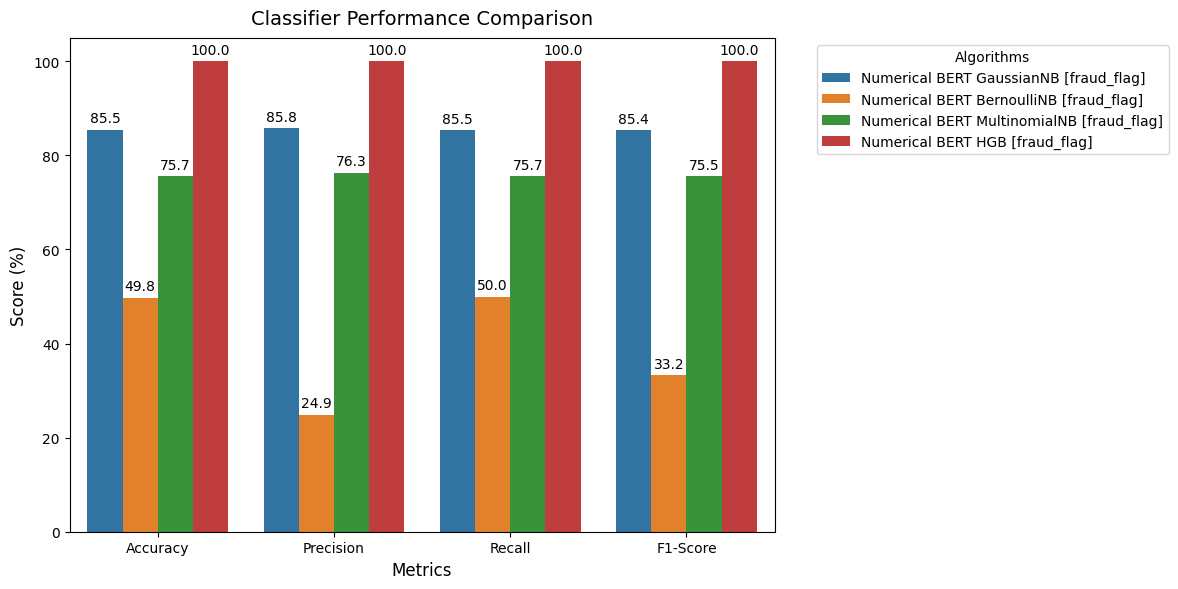

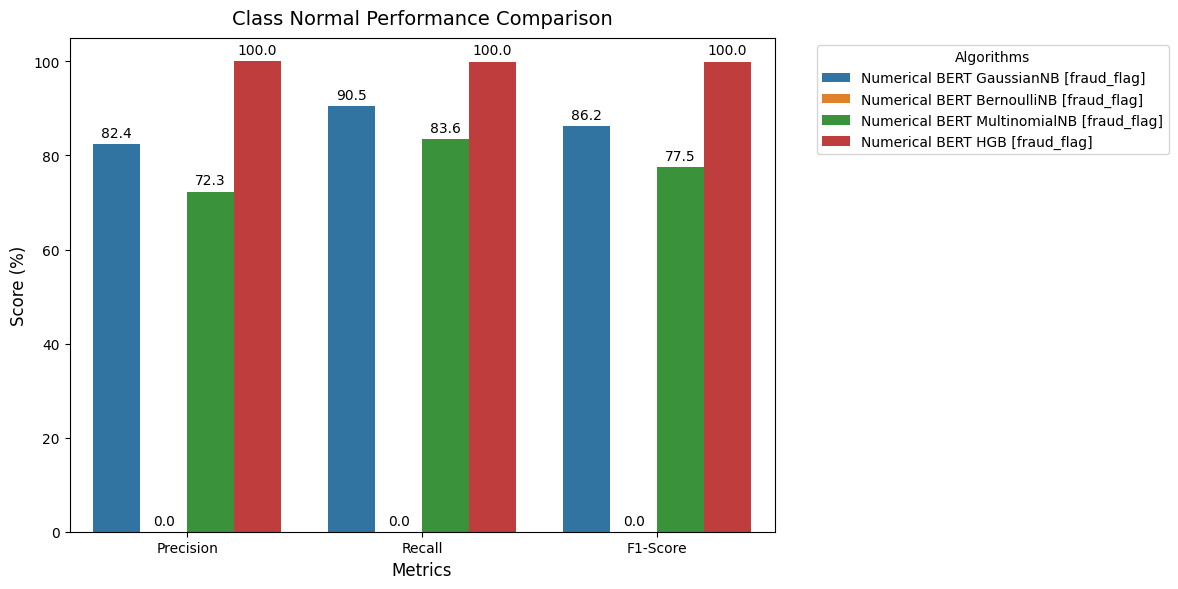

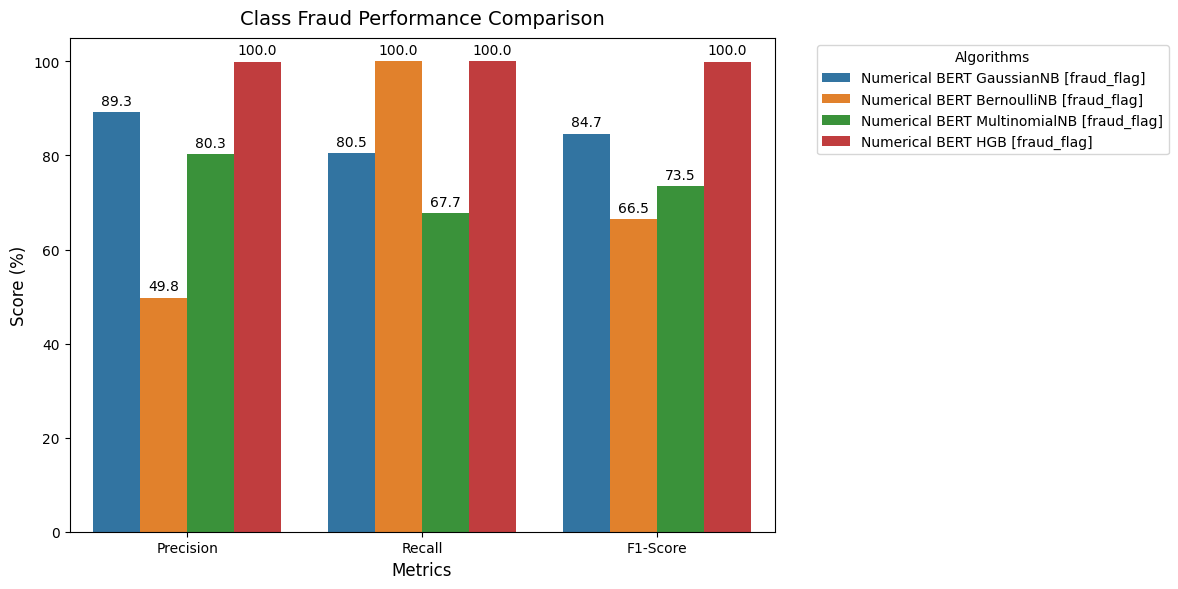

In [22]:
# Plot for Job Security
graph_plotter_wlb = GraphPlotter(metrics_calculator_wlb.metrics_df, metrics_calculator_wlb.class_performance_dfs)
graph_plotter_wlb.plot_all()

In [23]:
melted_df_wlb = metrics_calculator_wlb.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_wlb = melted_df_wlb.round(3)
melted_df_wlb

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Numerical BERT GaussianNB [fraud_flag],85.481,85.838,85.459,85.439
1,Numerical BERT BernoulliNB [fraud_flag],49.781,24.891,50.000,33.236
2,Numerical BERT MultinomialNB [fraud_flag],75.686,76.330,75.651,75.519
3,Numerical BERT HGB [fraud_flag],99.977,99.977,99.977,99.977


In [24]:
melted_df_cg = metrics_calculator_cg.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_cg = melted_df_cg.round(3)
melted_df_cg

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Numerical BERT GaussianNB [transaction_type],30.325,30.275,30.587,29.337
1,Numerical BERT BernoulliNB [transaction_type],24.072,6.018,25.000,9.701
2,Numerical BERT MultinomialNB [transaction_type],28.317,28.547,28.544,27.431
3,Numerical BERT HGB [transaction_type],84.443,84.333,84.661,84.440


In [25]:
test_path=r"Test_data.csv"

In [26]:
df_test1= upload_dataset(test_path)
df_test1
# Initialize result DataFrame
df_result = df_test1.copy()


In [27]:
df_test = preprocess_data(df_test1, mode='test')
df_test

[INFO] Mode: test
[INFO] Starting basic preprocessing...
[INFO] Applying NLP preprocessing on: ['transaction id', 'merchant_category', 'transaction_status', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']


100%|███████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 13314.19it/s]


,combined_text,amount (INR),hour_of_day,is_weekend,sender_age_group_min,sender_age_group_max,receiver_age_group_min,receiver_age_group_max
0,txn entertainment success tamil nadu indusind ...,442,20,1,26,35,26,35
1,txn shopping success tamil nadu hdfc icici and...,3678,9,0,46,55,18,25
2,txn grocery success andhra pradesh pnb hdfc an...,1909,17,0,18,25,0,0
3,txn utility success delhi yes bank icici io g ...,770,10,0,26,35,36,45
4,txn food success karnataka icici hdfc android ...,575,10,1,18,25,26,35
5,txn fuel success gujarat pnb pnb android g thu...,553,13,0,26,35,46,55
6,txn healthcare success delhi icici hdfc androi...,272,0,0,36,45,18,25
7,txn success karnataka indusind hdfc android g...,1596,13,0,26,35,18,25
8,txn entertainment success gujarat sbi axis and...,193,9,0,26,35,26,35
9,txn food success andhra pradesh sbi sbi androi...,139,14,0,26,35,18,25


In [28]:
features_test = feature_extraction(df_test,method='Numerical SBERT',is_train=None)

[INFO] Feature extraction method: Numerical SBERT, Train mode: None
[INFO] Computing SBERT features for test...


Extracting SBERT embeddings: 100%|███████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.24s/it]


In [29]:
fraud_labels = ["Normal", "Fraud"]
transaction_type_labels = ["Bill Payment", "P2M","P2P", "Recharge"]

features_test = feature_extraction(df_test,method='Numerical SBERT',is_train=None)
# Loop over each target
for target in ['transaction_type', 'fraud_flag']:

    # Predict using the model
    y_pred = histgb_models[target].predict(features_test)
    print(y_pred)
    # Fix label encoder if needed
    if target == 'transaction_type':
        label_encoders[target].classes_ = np.array(transaction_type_labels)
    elif target == 'fraud_flag':
        label_encoders[target].classes_ = np.array(fraud_labels)

    # Inverse transform to get original string labels
    mapped_labels = label_encoders[target].inverse_transform(y_pred)

    # Add prediction column
    df_result[f'Predicted_{target}'] = mapped_labels

# Final output
df_result

[INFO] Feature extraction method: Numerical SBERT, Train mode: None
[INFO] Computing SBERT features for test...


Extracting SBERT embeddings: 100%|███████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.90s/it]


[2 2 2 2 0 2 0 0 2 1 2 1 2 1 0 3 2 1 1 2 1 2 2 1 2 2 1 2 2 2 2 1 2 2 2 0 0
 0 2 2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1]


,transaction id,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,hour_of_day,day_of_week,is_weekend,Predicted_transaction_type,Predicted_fraud_flag
0,TXN0000071357,Entertainment,442,SUCCESS,26-35,26-35,Tamil Nadu,IndusInd,SBI,Android,4G,20,Saturday,1,P2P,Normal
1,TXN0000160021,Shopping,3678,SUCCESS,46-55,18-25,Tamil Nadu,HDFC,ICICI,Android,5G,9,Monday,0,P2P,Normal
2,TXN0000150232,Grocery,1909,SUCCESS,18-25,56+,Andhra Pradesh,PNB,HDFC,Android,5G,17,Thursday,0,P2P,Normal
3,TXN0000150202,Utilities,770,SUCCESS,26-35,36-45,Delhi,Yes Bank,ICICI,iOS,4G,10,Thursday,0,P2P,Normal
4,TXN0000086134,Food,575,SUCCESS,18-25,26-35,Karnataka,ICICI,HDFC,Android,5G,10,Sunday,1,Bill Payment,Normal
5,TXN0000043950,Fuel,553,SUCCESS,26-35,46-55,Gujarat,PNB,PNB,Android,5G,13,Thursday,0,P2P,Normal
6,TXN0000144992,Healthcare,272,SUCCESS,36-45,18-25,Delhi,ICICI,HDFC,Android,4G,0,Friday,0,Bill Payment,Normal
7,TXN0000051414,Other,1596,SUCCESS,26-35,18-25,Karnataka,IndusInd,HDFC,Android,4G,13,Friday,0,Bill Payment,Normal
8,TXN0000141754,Entertainment,193,SUCCESS,26-35,26-35,Gujarat,SBI,Axis,Android,WiFi,9,Monday,0,P2P,Normal
9,TXN0000132597,Food,139,SUCCESS,26-35,18-25,Andhra Pradesh,SBI,SBI,Android,5G,14,Friday,0,P2M,Normal
